# HRC event-region radius: obsid 19918

Chandra's `celldetect`/event-filtering steps constrain sources and events to a fixed
180 arcsec radius around the pointing (`filter_events`, `filter_sources`). Converting
that radius from arcsec into the sky-pixel units `dmcopy`'s region filter expects
requires the observation's actual pixel size. Both functions used a placeholder pixel
size of `1` arcsec/pixel for HRC instead of HRC's true `0.13180` arcsec/pixel, so the
"180 arcsec" region actually excluded any events or sources farther than about
**23.7 arcsec**, not 180 arcsec, from the pointing. ACIS is untouched (`pixel = 0.5`
either way).

This notebook reconstructs that bug by hand with the same CIAO commands
`filter_events` runs, against **obsid 19918** (IRAS 17020+4544, HRC-S) — the
observation where the bug was first noticed, because it has a real `celldetect` source
close enough to the *true* 180" aperture to belong, but close enough to the buggy
~23.7" one to fall right on its edge.

**Branch under review:** `stack/01-astroquery-and-hrc-scale`
**Fix location:** `astromon/observation.py`, `filter_events` / `filter_sources`


In [1]:
import math
import os
import subprocess
import sys
from pathlib import Path

REPO_DIR = "/Users/jean/git/astromon_project"
BRANCH = "stack/01-astroquery-and-hrc-scale"

# Import astromon from REPO_DIR explicitly, not whatever's ambiently importable --
# astromon 1.3.2 is also pip-installed in this environment, and silently picking
# that up instead of the checked-out branch would defeat the point of this
# notebook. REPO_DIR must have `stack/01-astroquery-and-hrc-scale` (or a branch
# built on it) checked out for this to demonstrate the fix.
sys.path.insert(0, REPO_DIR)
os.environ.setdefault("SKA", "/Users/jean/ska")

import matplotlib.pyplot as plt
import numpy as np
from astropy import coordinates as coords
from astropy.io import fits

from astromon import observation, utils

print("astromon imported from:", utils.__file__)

OBSID = 19918
BASE_WORK_DIR = "/Volumes/Black/data/astromon/work"
CIAO_PREFIX = "/Users/jean/miniforge3/envs/ciao-4.17"

RADIUS_NOMINAL_ARCSEC = 180.0
PIXEL_OLD_BUGGY = 1.0
PIXEL_NEW_FIXED = 0.13180

# These paths are this machine's CIAO install and the top-level directory this
# project caches observation working directories under -- not portable,
# matching this repo's other one-off review notebooks. BASE_WORK_DIR need not
# already contain obsid 19918; see the next cell.


astromon imported from: /Users/jean/git/astromon_project/astromon/utils.py


### Resolve obsid 19918's files, fetching from the archive if not cached

The raw event file is a public archive product: if it's not already under
`BASE_WORK_DIR`, fetch it with this project's own `Observation.download` (the same
call `filter_events`'s task pipeline makes) rather than reaching for CIAO's archive
tools directly. That method is already idempotent against *its own* downloads (a
marker file under `secondary/`), but that marker isn't part of this pre-existing
cache, so unconditionally calling it would re-download a file already sitting right
there -- hence the explicit existence check below instead of relying on it.

The celldetect source list (`sources/{obsid}_celldetect.src`) is a different kind of
input: not an archive product but a *derived* one, produced by running this
project's own detection pipeline on the event file. There's no equivalent
"just fetch it" for that -- regenerating it means actually running the pipeline
(`chandra_repro`, image-making, `celldetect`), which is a real per-obsid processing
job, not something to launch silently inside a validation notebook. If it's missing,
this raises with the exact command that produces it, instead of trying to run that
job inline.


In [2]:
def _obs_workdir(obsid: int, base_work_dir: str) -> Path:
    return Path(base_work_dir) / f"obs{obsid // 1000:02d}" / str(obsid)


def _find_evt2(workdir: Path) -> Path | None:
    matches = sorted((workdir / "primary").glob("*_evt2.fits*"))
    return matches[0] if matches else None


def resolve_evt2(obsid: int, base_work_dir: str, ciao_prefix: str) -> Path:
    """Return this obsid's raw event file, downloading it if not already cached."""
    workdir = _obs_workdir(obsid, base_work_dir)
    evt2 = _find_evt2(workdir)
    if evt2 is not None:
        print(f"using cached evt2: {evt2}")
        return evt2

    print(f"no cached evt2 under {workdir} -- downloading from the public archive")
    obs = observation.Observation(
        obsid, workdir=base_work_dir, source="archive", ciao_prefix=ciao_prefix
    )
    obs.download(["evt2"])
    evt2 = _find_evt2(workdir)
    if evt2 is None:
        raise FileNotFoundError(
            f"obsid {obsid}: download completed but no primary/*_evt2.fits* "
            f"file appeared under {workdir}"
        )
    print(f"downloaded evt2: {evt2}")
    return evt2


def resolve_celldetect_src(obsid: int, base_work_dir: str) -> Path:
    """Return this obsid's celldetect source list -- a pipeline-derived product,
    not an archive one, so there's no download fallback for it."""
    workdir = _obs_workdir(obsid, base_work_dir)
    src = workdir / "sources" / f"{obsid}_celldetect.src"
    if not src.exists():
        raise FileNotFoundError(
            f"{src} does not exist and can't be fetched from the archive -- it's "
            "produced by running this project's own detection pipeline on the "
            "event data, not a raw archive product. To generate it:\n"
            f"  python -m astromon.observation {obsid} --workdir {base_work_dir} "
            f"--ciao-prefix {ciao_prefix} --data-source archive"
        )
    return src


EVT2 = str(resolve_evt2(OBSID, BASE_WORK_DIR, CIAO_PREFIX))
CELLDETECT_SRC = str(resolve_celldetect_src(OBSID, BASE_WORK_DIR))


using cached evt2: /Volumes/Black/data/astromon/work/obs19/19918/primary/hrcf19918N002_evt2.fits.gz


## 1. What `stack/01-astroquery-and-hrc-scale` actually changes

Pulling the live diff (rather than hardcoding it) so this stays accurate if the branch moves.


In [3]:
diff_stat = subprocess.run(
    ["git", "diff", f"master...{BRANCH}", "--stat", "--", "astromon/observation.py"],
    cwd=REPO_DIR, capture_output=True, text=True, check=True,
).stdout
print(diff_stat)


 astromon/observation.py | 11 +++++------
 1 file changed, 5 insertions(+), 6 deletions(-)



In [4]:
diff_full = subprocess.run(
    ["git", "diff", f"master...{BRANCH}", "--", "astromon/observation.py"],
    cwd=REPO_DIR, capture_output=True, text=True, check=True,
).stdout
print(diff_full)


diff --git a/astromon/observation.py b/astromon/observation.py
index 9992e36..e632a8a 100644
--- a/astromon/observation.py
+++ b/astromon/observation.py
@@ -194,7 +194,7 @@ class Observation:
             self.archive_regex = archive_regex
         self._source = source
         logger.info(f"{self} starting. Context: {self.workdir}")
-        self._rebin = False
+        self._rebin = True
         self.ciao_ = None
         # ciao is initialized only if needed, but we make this check at the very beginning
         # so the user gets a warning at the top if calling CIAO will likely fail
@@ -1435,6 +1435,8 @@ def celldetect(obs, inputs, outputs):
     # possible parameter:
     snr = 3
 
+    # Note that the maxlogicalwindow needs to be bigger than whatever the
+    # binned filtered image is.
     obs.ciao(
         "celldetect",
         inputs["image_file"],
@@ -1500,8 +1502,7 @@ def filter_events(obs, inputs, outputs):
     # possible parameter:
     radius = 180  # radius in arcse

The branch also touches `cross_match.py` and `stored_result.py` (astroquery/task-related, unrelated to this bug) — not shown here so this stays focused on the HRC
region fix.

Two independent changes, both gated on `obs.is_hrc`:

- **Pixel size**: `pixel = 0.13180` (was `1`) in both `filter_events` and
  `filter_sources` — the placeholder used to convert the fixed 180" exclusion radius
  into sky-pixel units for `dmcopy`'s region filter. This is the part demonstrated
  below.
- **Rebin**: `self._rebin = True` (was `False`) — `make_images` bins HRC images by a
  factor of 4, giving the detection algorithms a pixel scale closer to what they
  expect instead of HRC's very fine native pixels. Not exercised in this notebook.


## 2. The mechanism: how `pixel` becomes a region radius

`filter_events` gets the pointing's sky (x, y) from `dmcoords`, then filters with
`dmcopy ... [(x,y)=circle(x, y, radius / pixel)]`. `dmcopy`'s circle radius is in the
same units as the event file's (x, y) columns — native sky pixels, not arcsec — so
`radius / pixel` is only correct if `pixel` is really that observation's arcsec/pixel.


In [5]:
r_old_px = RADIUS_NOMINAL_ARCSEC / PIXEL_OLD_BUGGY
r_new_px = RADIUS_NOMINAL_ARCSEC / PIXEL_NEW_FIXED

# The region's *actual* on-sky radius: however many sky pixels dmcopy was told to
# use, times HRC's true arcsec/pixel (the bug is in the radius passed to dmcopy, not
# in the file's own pixel scale).
old_actual_radius_arcsec = r_old_px * PIXEL_NEW_FIXED
new_actual_radius_arcsec = r_new_px * PIXEL_NEW_FIXED

print(f"nominal intended radius:        {RADIUS_NOMINAL_ARCSEC}\"")
print(f"OLD (buggy, pixel=1):   {r_old_px:8.3f} sky px -> actual radius {old_actual_radius_arcsec:6.3f}\"")
print(f"NEW (fixed, pixel={PIXEL_NEW_FIXED}): {r_new_px:8.3f} sky px -> actual radius {new_actual_radius_arcsec:6.3f}\"")


nominal intended radius:        180.0"
OLD (buggy, pixel=1):    180.000 sky px -> actual radius 23.724"
NEW (fixed, pixel=0.1318): 1365.706 sky px -> actual radius 180.000"


## 3. Obsid 19918's `celldetect` sources against both radii

`celldetect` runs on the full, unfiltered image, so it finds every source within the *true* 180" aperture regardless of this bug. The question is which of those sources the buggy event/source filter would then have clipped.


In [6]:
with fits.open(CELLDETECT_SRC) as hdul:
    hdr = hdul[1].header
    src = hdul[1].data
    ra_pnt, dec_pnt = hdr["RA_PNT"], hdr["DEC_PNT"]

pnt = coords.SkyCoord(ra_pnt, dec_pnt, unit="deg")
src_coord = coords.SkyCoord(src["RA"], src["DEC"], unit="deg")
sep_arcsec = pnt.separation(src_coord).arcsec

print(f"pointing: RA={ra_pnt:.6f}  DEC={dec_pnt:.6f}\n")
header = f"{'#':>2} {'sep (\")':>9} {'inside OLD':>11} {'inside NEW':>11} {'NET_COUNTS':>11}"
print(header)
for i in range(len(src)):
    d = sep_arcsec[i]
    print(f"{i:>2} {d:>9.3f} {str(d <= old_actual_radius_arcsec):>11} "
          f"{str(d <= new_actual_radius_arcsec):>11} {src['NET_COUNTS'][i]:>11.2f}")


pointing: RA=255.873884  DEC=45.673253

 #   sep (")  inside OLD  inside NEW  NET_COUNTS
 0    33.877       False        True       23.14
 1    24.525       False        True     3421.86
 2    41.396       False        True       27.00
 3   167.723       False        True       33.15
 4   178.350       False        True       29.95
 5   177.436       False        True       30.91


Source #1 is the bright one (`NET_COUNTS` two to three orders of magnitude above the
rest — the science target itself) at ~24.5" separation: comfortably inside the true
180" aperture, but only ~0.8" outside the buggy ~23.7" one. That's the source right on
the edge.


## 4. Constructing both regions with live CIAO commands

The same `dmkeypar` / `dmcoords` / `dmcopy` sequence `filter_events` runs, called by
hand with each `pixel` value.

`stack/01-astroquery-and-hrc-scale` sits early enough in the stack that `utils.Ciao`
doesn't yet know how to run a conda-packaged CIAO install ("Run the pipeline off the
CXC network" adds that later) -- without it, `Ciao.__init__` assumes `ciao.sh` sets
`ASCDS_INSTALL` the way a traditional install's does, which conda's no-op `ciao.sh`
never does. Pre-seeding `Ciao`'s own env cache below with what that later fix builds
means this notebook runs the same regardless of which point in the stack `utils.py`
came from -- `CIAO_ENV` exists on both sides of that fix, it's only the fallback for
a miss that doesn't yet.


In [7]:
import tempfile

ciao_prefix_path = Path(CIAO_PREFIX)
if "ASCDS_INSTALL" not in utils.CIAO_ENV.get(ciao_prefix_path, {}):
    conda_env = dict(os.environ)
    conda_env["ASCDS_INSTALL"] = str(ciao_prefix_path)
    conda_env["ASCDS_CONTRIB"] = str(ciao_prefix_path)
    conda_env["ASCDS_CALIB"] = str(ciao_prefix_path / "data")
    caldb = str(ciao_prefix_path / "CALDB")
    conda_env["CALDB"] = caldb
    conda_env["CALDBCONFIG"] = caldb + "/software/tools/caldb.config"
    conda_env["CALDBALIAS"] = caldb + "/software/tools/alias_config.fits"
    conda_env["PATH"] = str(ciao_prefix_path / "bin") + ":" + conda_env.get("PATH", "/usr/bin:/bin")
    utils.CIAO_ENV[ciao_prefix_path] = conda_env
    print(f"pre-seeded a conda-CIAO env for {ciao_prefix_path}")
else:
    print(f"utils.Ciao already has a usable env for {ciao_prefix_path}")

workdir = tempfile.mkdtemp(prefix="hrc_19918_bug_demo_")
ciao = utils.Ciao(prefix=CIAO_PREFIX, workdir=workdir, logger="hrc_demo")

ciao("dmkeypar", EVT2, "RA_PNT")
ra_pnt = float(ciao.pget("dmkeypar"))  # same value as the FITS header in section 3,
ciao("dmkeypar", EVT2, "DEC_PNT")      # gotten the way filter_events itself gets it
dec_pnt = float(ciao.pget("dmkeypar"))

ciao("punlearn", "dmcoords")
ciao("dmcoords", EVT2, op="cel", celfmt="deg", ra=ra_pnt, dec=dec_pnt)
x_pnt = float(ciao.pget("dmcoords", "x"))
y_pnt = float(ciao.pget("dmcoords", "y"))
print(f"pointing sky (x, y) = ({x_pnt}, {y_pnt})")


pre-seeded a conda-CIAO env for /Users/jean/miniforge3/envs/ciao-4.17


pointing sky (x, y) = (32768.19737072248, 32767.95172171025)


In [8]:
evt_old = f"{workdir}/19918_evt2_filtered_OLD_buggy.fits"
evt_new = f"{workdir}/19918_evt2_filtered_NEW_fixed.fits"

ciao("dmcopy", f"{EVT2}[(x,y)=circle({x_pnt},{y_pnt},{r_old_px})]", evt_old, clobber="yes")
ciao("dmcopy", f"{EVT2}[(x,y)=circle({x_pnt},{y_pnt},{r_new_px})]", evt_new, clobber="yes")
print("wrote", evt_old)
print("wrote", evt_new)


wrote /var/folders/f2/0_51vbvs2lg1cdt89x1lrdnr0000gp/T/hrc_19918_bug_demo_567gegls/19918_evt2_filtered_OLD_buggy.fits
wrote /var/folders/f2/0_51vbvs2lg1cdt89x1lrdnr0000gp/T/hrc_19918_bug_demo_567gegls/19918_evt2_filtered_NEW_fixed.fits


## 5. Event-level confirmation

Does the OLD region actually cut off source #1's photons?


In [9]:
# Source #1's sky (x, y), via the same dmcoords call filter_events uses.
src1_ra, src1_dec = src["RA"][1], src["DEC"][1]
ciao("punlearn", "dmcoords")
ciao("dmcoords", EVT2, op="cel", celfmt="deg", ra=src1_ra, dec=src1_dec)
sx = float(ciao.pget("dmcoords", "x"))
sy = float(ciao.pget("dmcoords", "y"))
pixel_dist = math.hypot(sx - x_pnt, sy - y_pnt)

print(f"source #1 sky (x, y) = ({sx:.3f}, {sy:.3f})")
print(f"distance from pointing: {pixel_dist:.3f} sky px "
      f"(OLD region radius {r_old_px:.3f} px, NEW region radius {r_new_px:.3f} px)")
print(f"margin by which source #1 misses the OLD boundary: "
      f"{pixel_dist - r_old_px:.3f} sky px ({(pixel_dist - r_old_px) * PIXEL_NEW_FIXED:.3f}\")")


source #1 sky (x, y) = (32713.551, 32945.816)
distance from pointing: 186.070 sky px (OLD region radius 180.000 px, NEW region radius 1365.706 px)
margin by which source #1 misses the OLD boundary: 6.070 sky px (0.800")


In [10]:
counts = {}
for label, path in [("OLD (buggy)", evt_old), ("NEW (fixed)", evt_new)]:
    with fits.open(path) as hdul:
        data = hdul[1].data
        dist = np.hypot(data["x"] - sx, data["y"] - sy)
        counts[label] = {
            "n_total": len(data),
            "n_near_source1": int((dist < 20).sum()),  # within 20 sky px (~2.6") of source #1
        }

for label, c in counts.items():
    print(f"{label:14s}: total events = {c['n_total']:7,d}   "
          f"events within 20 px of source #1 = {c['n_near_source1']:5,d}")


OLD (buggy)   : total events =   3,258   events within 20 px of source #1 =   172
NEW (fixed)   : total events = 114,821   events within 20 px of source #1 = 3,711


The OLD region keeps only a small, one-sided sliver of source #1's own PSF (the part
of its 20 px check-aperture that happens to dip inside the buggy 180 px-radius
boundary) instead of the source's full profile — a severe truncation, not just a
missing background events, for the observation's own science target.


## 6. Visual: both regions against the real source positions


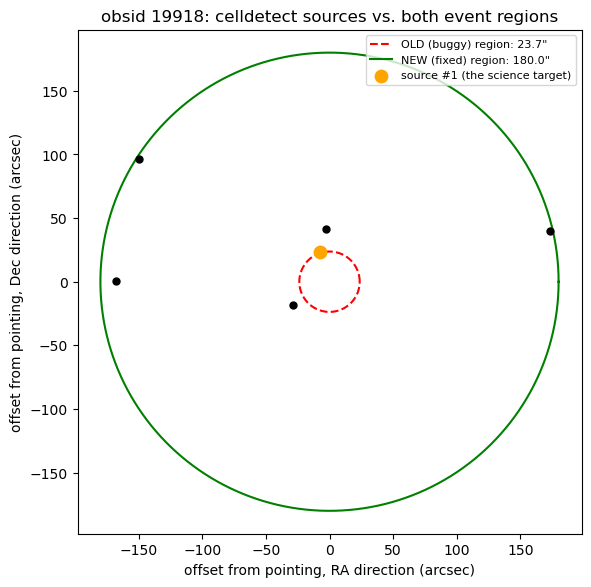

In [11]:
dx_arcsec = (src["RA"] - ra_pnt) * np.cos(np.radians(dec_pnt)) * 3600 * -1
dy_arcsec = (src["DEC"] - dec_pnt) * 3600

fig, ax = plt.subplots(figsize=(6, 6))
for r, label, style in [
    (old_actual_radius_arcsec, "OLD (buggy) region", "r--"),
    (new_actual_radius_arcsec, "NEW (fixed) region", "g-"),
]:
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(r * np.cos(theta), r * np.sin(theta), style, label=f"{label}: {r:.1f}\"")

ax.scatter(dx_arcsec, dy_arcsec, c="k", s=25, zorder=5)
ax.scatter(dx_arcsec[1], dy_arcsec[1], c="orange", s=80, zorder=6,
           label="source #1 (the science target)")
ax.set_xlabel("offset from pointing, RA direction (arcsec)")
ax.set_ylabel("offset from pointing, Dec direction (arcsec)")
ax.set_title(f"obsid {OBSID}: celldetect sources vs. both event regions")
ax.set_aspect("equal")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()


## Summary

Automated pass/fail based on the checks above.


In [12]:
checks = {
    "OLD region's actual radius is ~23.7\", not the intended 180\"":
        math.isclose(old_actual_radius_arcsec, 23.724, abs_tol=0.01),
    "NEW region's actual radius is the intended 180\"":
        math.isclose(new_actual_radius_arcsec, 180.0, abs_tol=0.01),
    "source #1 is within the true 180\" aperture": sep_arcsec[1] <= new_actual_radius_arcsec,
    "source #1 falls outside the OLD buggy region": sep_arcsec[1] > old_actual_radius_arcsec,
    "source #1 misses the OLD boundary by less than 1\"":
        0 < (sep_arcsec[1] - old_actual_radius_arcsec) < 1.0,
    "OLD filtered event file has far fewer events than NEW":
        counts["OLD (buggy)"]["n_total"] < counts["NEW (fixed)"]["n_total"] / 10,
    "OLD region captures well under half of source #1's own events":
        counts["OLD (buggy)"]["n_near_source1"] < counts["NEW (fixed)"]["n_near_source1"] / 2,
}
for name, ok in checks.items():
    print(("PASS" if ok else "FAIL"), "--", name)
print()
print("ALL CHECKS PASSED" if all(checks.values()) else "SOME CHECKS FAILED")


PASS -- OLD region's actual radius is ~23.7", not the intended 180"
PASS -- NEW region's actual radius is the intended 180"
PASS -- source #1 is within the true 180" aperture
PASS -- source #1 falls outside the OLD buggy region
PASS -- source #1 misses the OLD boundary by less than 1"
PASS -- OLD filtered event file has far fewer events than NEW
PASS -- OLD region captures well under half of source #1's own events

ALL CHECKS PASSED
